In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter()

import colour

from colour_demosaicing import (
    ROOT_RESOURCES_EXAMPLES,
    demosaicing_CFA_Bayer_bilinear,
    demosaicing_CFA_Bayer_Malvar2004,
    demosaicing_CFA_Bayer_Menon2007,
    mosaicing_CFA_Bayer,
)

In [2]:
data_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [8]:
data = np.swapaxes(
    np.moveaxis(
        IO.read_tiff(
            "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour/MIP_TAB-PAINT/MIP_TAB_PAINT.tif"
        ),
        1,
        -1,
    ),
    0,
    1,
)

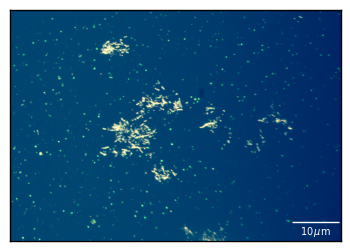

In [19]:
fig, axs = plotter.two_column_plot()
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

axs.imshow(np.asarray(data, dtype=int), origin="lower")
axs.set_xticks([])
axs.set_yticks([])

labelcolor = "white"
fontsz = 8
pixelsize = 69
scalebarsize = 10000
label = ""
labelcolor = "white"
scalebarlabel = r"10$\,\mu$m"
pixvals = scalebarsize / pixelsize
scalebar = AnchoredSizeBar(
    axs.transData,
    pixvals,
    scalebarlabel,
    "lower right",
    pad=0.1,
    color=labelcolor,
    frameon=False,
    size_vertical=1,
)

axs.add_artist(scalebar)
axs.annotate(
    label,
    xy=(5, 5),
    xytext=(20, 60),
    xycoords="data",
    color=labelcolor,
    fontsize=fontsz - 1,
)


folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour"
plt.savefig(os.path.join(folder, "TAB-PAINT.svg"), format="svg", dpi=600)

In [ ]:
plt.imshow(TAB_RGB_MIP / np.max(TAB_RGB_MIP))

In [ ]:
ground_truth, bayer_image = MSF.gen_camera_images(
    camera_calibration,
    wavelength,
    absolute_QYs,
    dyes,
    n_photons,
    x0y0,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
)

In [ ]:
import denoisetools as ncs

In [ ]:
test = np.expand_dims(bayer_image, 0)
PixelSize = pixel_size / 1000
Lambda = 0.6
alpha = 0.2
R = 1
out = ncs.reducenoise(
    R,
    test,
    camera_calibration["variance"],
    camera_calibration["gain"],
    image_size,
    pixelsize=PixelSize,
    NA=NA,
    Lambda=Lambda,
    alpha=alpha,
    iterationN=15,
)

In [ ]:
fig, axs = plotter.two_column_plot(widthratio=[1, 1], ncolumns=2)

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=bayer_image,
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)
axs[1] = plotter.image_plot(
    axs=axs[1],
    data=out[0, :, :],
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour"
plt.savefig(
    os.path.join(
        folder, "PSF_ATTO390_ATTO550_ATTO655_ATTO740_4000photons_denoised.svg"
    ),
    format="svg",
    dpi=600,
)

In [ ]:
fig, axs = plotter.two_column_plot(
    widthratio=[1, 1], heightratio=[1, 1], ncolumns=2, nrows=2
)

axs[0, 0] = plotter.image_plot(
    axs=axs[0, 0],
    data=ground_truth.values[:, :, 0],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 0] = plotter.image_plot(
    axs=axs[1, 0],
    data=ground_truth.values[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[0, 1] = plotter.image_plot(
    axs=axs[0, 1],
    data=ground_truth.values[:, :, 2],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 1] = plotter.image_plot(
    axs=axs[1, 1],
    data=bayer_image[:, :],
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
)

plt.tight_layout()
# folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour'
# plt.savefig(os.path.join(folder, 'PSF_ATTO390_ATTO550_ATTO655_ATTO740_4000photons.svg'), format='svg', dpi=600)

In [ ]:
smoothed_image = np.median(bayer_image)

Bilinear = colour.cctf_encoding(demosaicing_CFA_Bayer_bilinear(bayer_image))
Bilinear = Bilinear / (np.median(np.median(Bilinear, axis=1), axis=0) / smoothed_image)
Malvar = colour.cctf_encoding(demosaicing_CFA_Bayer_Malvar2004(bayer_image))
Malvar = Malvar / (np.median(np.median(Malvar, axis=1), axis=0) / smoothed_image)
Menon = colour.cctf_encoding(demosaicing_CFA_Bayer_Menon2007(bayer_image))
Menon = Menon / (np.median(np.median(Menon, axis=1), axis=0) / smoothed_image)

fig, axs = plotter.two_column_plot(
    widthratio=[1, 1, 1, 1], heightratio=[1, 1, 1], ncolumns=4, nrows=3
)

axs[0, 0] = plotter.image_plot(
    axs=axs[0, 0],
    data=ground_truth.values[:, :, 0],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 0] = plotter.image_plot(
    axs=axs[1, 0],
    data=ground_truth.values[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[2, 0] = plotter.image_plot(
    axs=axs[2, 0],
    data=ground_truth.values[:, :, 2],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)

axs[0, 1] = plotter.image_plot(
    axs=axs[0, 1],
    data=Bilinear[:, :, 2],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 1] = plotter.image_plot(
    axs=axs[1, 1],
    data=Bilinear[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[2, 1] = plotter.image_plot(
    axs=axs[2, 1],
    data=Bilinear[:, :, 0],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)

axs[0, 2] = plotter.image_plot(
    axs=axs[0, 2],
    data=Malvar[:, :, 2],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 2] = plotter.image_plot(
    axs=axs[1, 2],
    data=Malvar[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[2, 2] = plotter.image_plot(
    axs=axs[2, 2],
    data=Malvar[:, :, 0],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)

axs[0, 3] = plotter.image_plot(
    axs=axs[0, 3],
    data=Menon[:, :, 2],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 3] = plotter.image_plot(
    axs=axs[1, 3],
    data=Menon[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[2, 3] = plotter.image_plot(
    axs=axs[2, 3],
    data=Menon[:, :, 0],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)

plt.tight_layout()

Rerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 2] - Bilinear[:, :, 0])))
Gerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 1] - Bilinear[:, :, 1])))
Berror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 0] - Bilinear[:, :, 2])))
print(np.mean([Rerror, Gerror, Berror]))

Rerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 2] - Malvar[:, :, 0])))
Gerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 1] - Malvar[:, :, 1])))
Berror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 0] - Malvar[:, :, 2])))
print(np.mean([Rerror, Gerror, Berror]))

Rerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 2] - Menon[:, :, 0])))
Gerror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 1] - Menon[:, :, 1])))
Berror = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 0] - Menon[:, :, 2])))
print(np.mean([Rerror, Gerror, Berror]))

# folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour'
# plt.savefig(os.path.join(folder, 'PSF_ATTO390_ATTO550_ATTO655_ATTO740_4000photons_Reconstructions.svg'), format='svg', dpi=600)

In [ ]:
n_photon_lspace = np.linspace(500, 20000, 1000)
n_bootstrap = 1000

estimator_error_mean = np.zeros([3, len(n_photon_lspace)])
estimator_error_std = np.zeros([3, len(n_photon_lspace)])

start = time.time()
for i, photon_number in enumerate(n_photon_lspace):
    n_photons = {}
    n_photons["ATTO390"] = photon_number
    n_photons["ATTO550"] = photon_number
    n_photons["ATTO655"] = photon_number
    n_photons["ATTO740"] = photon_number
    estimator_error = np.zeros([3, n_bootstrap])
    for j in np.arange(n_bootstrap):
        ground_truth, bayer_image = MSF.gen_camera_images(
            camera_calibration,
            wavelength,
            absolute_QYs,
            dyes,
            n_photons,
            x0y0,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
        )

        Bilinear = colour.cctf_encoding(demosaicing_CFA_Bayer_bilinear(bayer_image))
        Bilinear = Bilinear / (
            np.median(np.median(Bilinear, axis=1), axis=0) / np.median(bayer_image)
        )
        Malvar = colour.cctf_encoding(demosaicing_CFA_Bayer_Malvar2004(bayer_image))
        Malvar = Malvar / (
            np.median(np.median(Malvar, axis=1), axis=0) / np.median(bayer_image)
        )
        Menon = colour.cctf_encoding(demosaicing_CFA_Bayer_Menon2007(bayer_image))
        Menon = Menon / (
            np.max(np.median(Menon, axis=1), axis=0) / np.median(bayer_image)
        )

        # do bilinear errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Bilinear[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Bilinear[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Bilinear[:, :, 2]))
        )
        estimator_error[0, j] = np.mean([Rerror, Gerror, Berror])

        # do Malvar errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Malvar[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Malvar[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Malvar[:, :, 2]))
        )
        estimator_error[1, j] = np.mean([Rerror, Gerror, Berror])

        # do Menon errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Menon[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Menon[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Menon[:, :, 2]))
        )
        estimator_error[2, j] = np.mean([Rerror, Gerror, Berror])

    estimator_error_mean[:, i] = np.mean(estimator_error, axis=1)
    estimator_error_std[:, i] = np.std(estimator_error, axis=1)

    print(
        "Analysed photon flux {}/{}    Time elapsed: {:.3f} s".format(
            i + 1, len(n_photon_lspace), time.time() - start
        ),
        end="\r",
        flush=True,
    )

In [ ]:
columns = [
    "Bilinear",
    "Malvar",
    "Menon",
]

means = pl.DataFrame(data=estimator_error_mean, schema=columns)
stds = pl.DataFrame(data=estimator_error_std, schema=columns)

save_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241011/data"
means.write_csv(os.path.join(save_folder, "Estimator_RMSE_mean_MEDIAN.csv"))
stds.write_csv(os.path.join(save_folder, "Estimator_RMSE_std_MEDIAN.csv"))

In [ ]:
save_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241011/data"
means = pl.read_csv(os.path.join(save_folder, "Estimator_RMSE_mean_MEDIAN.csv"))
stds = pl.read_csv(os.path.join(save_folder, "Estimator_RMSE_std_MEDIAN.csv"))

In [ ]:
fig, axs = plotter.one_column_plot()

n_photon_lspace = np.linspace(500, 20000, 1000)


axs = plotter.line_error_plot(
    axs=axs,
    x=n_photon_lspace,
    y=means["Bilinear"].to_numpy(),
    yerror=stds["Bilinear"].to_numpy(),
    color="k",
    label="Bilinear",
    alpha=0.5,
)
axs = plotter.line_error_plot(
    axs=axs,
    x=n_photon_lspace,
    y=means["Malvar"].to_numpy(),
    yerror=stds["Malvar"].to_numpy(),
    ls=":",
    label="Malvar",
    alpha=0.5,
    color="#cb6751",
)
axs = plotter.line_error_plot(
    axs=axs,
    x=n_photon_lspace,
    y=means["Menon"].to_numpy(),
    yerror=stds["Menon"].to_numpy(),
    label="Menon",
    ls="--",
    alpha=0.5,
    color="#7aa457",
    xaxislabel="photons hitting detector",
    yaxislabel="RMSE",
)


plt.legend(fontsize=6, loc="best")
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour"
plt.savefig(os.path.join(folder, "Estimator_Error_MEDIAN.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
n_photon_lspace = np.linspace(500, 20000, 1000)
n_bootstrap = 1000

dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)
percentage_on_pixel = [dye_pixel_efficiency.T / np.sum(dye_pixel_efficiency, axis=1)].T

colour_mean = np.zeros([3, len(n_photon_lspace), dyes.shape[0]])
colour_std = np.zeros([3, len(n_photon_lspace), dyes.shape[0]])

start = time.time()
for i, photon_number in enumerate(n_photon_lspace):
    n_photons = {}
    n_photons["ATTO390"] = photon_number
    n_photons["ATTO550"] = photon_number
    n_photons["ATTO655"] = photon_number
    n_photons["ATTO740"] = photon_number
    colour_vals = np.zeros([3, n_bootstrap])
    for j in np.arange(n_bootstrap):
        ground_truth, bayer_image = MSF.gen_camera_images(
            camera_calibration,
            wavelength,
            absolute_QYs,
            dyes,
            n_photons,
            x0y0,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
        )

        ATTO390 = np.array([[6, 22], [8, 20]])
        ATTO550 = np.array([[20, 40], [5, 22]])
        ATTO655 = np.array([[5, 25], [20, 40]])
        ATTO740 = np.array([[4, 24], [18, 40]])

        Malvar = colour.cctf_encoding(demosaicing_CFA_Bayer_Malvar2004(bayer_image))
        Malvar = Malvar / (
            np.median(np.median(Malvar, axis=1), axis=0) / np.median(bayer_image)
        )

        # do Malvar errors
        Gv = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 1] - Malvar[:, :, 1])))
        Bv = np.mean(np.sqrt(np.square(ground_truth.values[:, :, 0] - Malvar[:, :, 2])))
        colour_vals[1, j] = np.mean([Rerror, Gerror, Berror])

    estimator_error_mean[:, i] = np.mean(estimator_error, axis=1)
    estimator_error_std[:, i] = np.std(estimator_error, axis=1)

    print(
        "Analysed photon flux {}/{}    Time elapsed: {:.3f} s".format(
            i + 1, len(n_photon_lspace), time.time() - start
        ),
        end="\r",
        flush=True,
    )